In [1]:
import uproot 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import seaborn as sns
import plotly.express as px


In [2]:
total_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'L_MASS'] 

preslectrion_keys = ['SUMCHI2','Cos_xi_LbP','Cos_xi_LP','xi_LbP', 'xi_LP' ] # ,'xi_LbP', 'xi_LP' 



training_variables = total_keys+preslectrion_keys

In [3]:
# preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
# preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (p_PID_P > 0) & (Jpsi_MAXDOCA < 0.15) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0)  & (p_PID_P > 0) & (Jpsi_MAXDOCA < 0.15) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150)  & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '

second_cuts = '(p_PID_P > 0 )'
second_cuts_mc = '(p_PID_P > 0 )'
# second_cuts = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'
# second_cuts_mc = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'

In [4]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ'] + ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data2 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'],library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data3 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data4 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_data5 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data6 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data7 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data8 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")

mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_bkg= mc_background_merge.query(preselection_cut_mc)

#Creates a new variables like the Cos()...
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data
mc_signal['Cos_xi_LbP'] = cos_xi_Lb
mc_signal['Cos_xi_LP'] = cos_xi_L
mc_signal['xi_LP'] = xi_L
mc_signal['xi_LbP'] = xi_Lb
mc_signal['SUMCHI2'] = mc_signal['L_CHI2'] + mc_signal['Lb_CHI2'] + mc_signal['Jpsi_CHI2']
# mc_signal_selected_chi2  = mc_signal[mc_signal.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_signal['SUMCHI2']].drop_duplicates('EVENTNUMBER')
# mc_signal_selected  = mc_signal_selected_chi2[mc_signal_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_signal_selected_chi2['p_PID_P']].drop_duplicates()

mc_signal_selected = mc_signal

#Creates a new variables like the Cos()...

cos_xi_L = ((mc_bkg['p_PX']*mc_bkg['L_PX']+mc_bkg['p_PY']*mc_bkg['L_PY']+mc_bkg['p_PZ']*mc_bkg['L_PZ'])/(mc_bkg['p_P']*mc_bkg['L_P']))
cos_xi_Lb = ((mc_bkg['p_PX']*mc_bkg['Lb_PX']+mc_bkg['p_PY']*mc_bkg['Lb_PY']+mc_bkg['p_PZ']*mc_bkg['Lb_PZ'])/(mc_bkg['p_P']*mc_bkg['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data

mc_bkg['Cos_xi_LP'] = cos_xi_L
mc_bkg['Cos_xi_LbP'] = cos_xi_Lb
mc_bkg['xi_LP'] = xi_L
mc_bkg['xi_LbP'] = xi_Lb
mc_bkg['SUMCHI2'] = mc_bkg['L_CHI2'] + mc_bkg['Lb_CHI2'] + mc_bkg['Jpsi_CHI2']
# mc_bkg_selected_chi2  = mc_bkg[mc_bkg.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_bkg['SUMCHI2']].drop_duplicates('EVENTNUMBER')
# mc_bkg_selected  = mc_bkg_selected_chi2[mc_bkg_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_bkg_selected_chi2['p_PID_P']].drop_duplicates()
mc_bkg_selected = mc_bkg 

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_7715/2138216427.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LbP'] = cos_xi_Lb
/tmp/javeser/ipykernel_7715/2138216427.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LP'] = cos_xi_L
/tmp/javeser/ipykernel_7715/2138216427.py:37: SettingWithCopyWarning: 
A

In [5]:
data24 = pd.read_pickle('data24_magup_training.pkl')

#Creates a new variables like the Cos()...

cos_xi_L_data = ((data24['p_PX']*data24['L_PX']+data24['p_PY']*data24['L_PY']+data24['p_PZ']*data24['L_PZ'])/(data24['p_P']*data24['L_P']))
cos_xi_Lb_data = ((data24['p_PX']*data24['Lb_PX']+data24['p_PY']*data24['Lb_PY']+data24['p_PZ']*data24['Lb_PZ'])/(data24['p_P']*data24['Lb_P']))
xi_L_data = np.arccos(cos_xi_L_data)
xi_Lb_data  = np.arccos(cos_xi_Lb_data)

#Add the new varaibles to signal_data
data24['Cos_xi_LP'] = cos_xi_L_data
data24['Cos_xi_LbP'] = cos_xi_Lb_data
data24['xi_LP'] = xi_L_data
data24['xi_LbP'] = xi_Lb_data

data24_selected = data24

data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']
# data24_selected_chi2  = data24[data24.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==data24['SUMCHI2']].drop_duplicates('EVENTNUMBER')
# data24_selected  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
mc_signal_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,Lb_PZ,Lb_MASS,EVENTNUMBER,Jpsi_P,mum_PID_MU,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,195492.234375,5282.650391,1049619,105929.203125,3.958498,0.999610,0.999784,0.020791,0.027938,7.188199
1,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,95583.171875,5621.771973,155975,47822.925781,5.927719,0.999945,0.999758,0.021981,0.010484,3.564506
2,36.637245,204.355850,0.999998,8.861835,1.525625,1.000000,0.013432,0.508896,2.389404,116028.679688,...,115988.398438,5729.892578,484136,45909.937500,7.632055,0.999986,0.999851,0.017250,0.005338,1.945351
3,38.721493,316.204285,0.999998,9.750591,0.333755,0.999998,0.008024,0.138330,9.783347,95800.343750,...,95752.500000,5583.860352,361232,50192.734375,6.558467,0.999369,0.999833,0.018286,0.035517,11.039947
4,46.746983,292.921631,0.999995,20.399487,4.260338,0.999996,0.050449,0.366285,18.198738,77709.648438,...,77690.421875,5124.538086,1031816,36525.070312,5.934614,0.999656,0.999989,0.004632,0.026225,11.015934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45179,40760.289062,583.265564,1.000000,1.582811,0.033018,1.000000,0.003236,4.341070,1.577042,456679.968750,...,454134.031250,5617.005859,567579,396666.781250,3.101420,0.999866,0.999909,0.013527,0.016374,0.118149
45182,43327.621094,986.644653,0.999999,12.130662,NaN,1.000000,0.005436,0.937817,1.115114,401201.125000,...,397815.187500,5615.601074,192056,336292.718750,3.990870,0.999872,0.999996,0.002719,0.015998,3.536717
45185,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,529821.312500,5508.531738,465504,453172.000000,7.714198,0.999999,0.999722,0.023598,0.001505,7.843421
45186,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,396416.375000,5658.234863,1036722,344304.687500,5.452041,0.999932,0.999895,0.014493,0.011673,1.460683


In [7]:
mc_bkg_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,Lb_PZ,Lb_MASS,EVENTNUMBER,Jpsi_P,mum_PID_MU,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
1,6.139585,91.591812,0.999991,21.584637,5.397385,0.996216,0.089235,0.084741,11.567128,86401.679688,...,86395.593750,5999.031250,1205459,30389.341797,10.390567,0.999495,0.999267,0.031779,0.038285,10.848227
2,19.314734,135.128021,0.999997,11.173959,0.388747,0.999982,0.052048,0.162292,8.909716,188634.140625,...,188616.515625,5688.728027,1049619,105929.203125,3.958498,0.999882,0.999606,0.015364,0.028085,0.843840
5,19.314734,185.730194,0.999997,14.878242,10.207611,0.999964,0.073177,0.161870,9.451078,164147.312500,...,164138.671875,5344.718750,1049619,105929.203125,3.958498,0.998892,0.998168,0.047079,0.060535,19.892063
6,19.314734,244.105698,0.999997,17.592119,5.809609,0.999973,0.063333,0.162369,17.529881,167697.343750,...,167684.156250,5543.265137,1049619,105929.203125,3.958498,0.999966,0.999580,0.008192,0.028991,37.981252
7,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,85681.718750,5012.679688,155975,47822.925781,5.927719,0.999909,0.999238,0.013474,0.039031,3.840920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131507,41939.519531,338.024292,0.999995,13.068227,0.742684,0.999999,0.094210,5.671501,5.928489,610229.500000,...,608195.500000,5332.169434,1142272,515666.593750,7.523288,0.999909,0.999773,0.013523,0.021323,3.055526
131508,42084.796875,1159.282959,1.000000,3.715287,0.223125,0.999999,0.014131,2.079864,0.993393,326976.593750,...,320141.531250,6305.155762,723945,198815.609375,6.342951,0.999909,0.999627,0.013496,0.027321,0.296616
131510,42969.351562,293.074646,0.999996,12.274388,5.770057,1.000000,0.005342,1.443463,11.324803,601135.062500,...,599401.437500,6061.737305,1144218,560168.687500,6.084399,0.999712,0.999850,0.023994,0.017346,7.270323
131513,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,864902.937500,5969.040039,1016434,808975.312500,8.069694,0.999704,0.999491,0.024349,0.031914,6.704729


In [8]:
data24_selected

,Jpsi_PT,Jpsi_CHI2,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_MASS,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,...,L_PY,L_PZ,Lb_PX,Lb_PY,Lb_PZ,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
0,1.118258,1.766955,149.676483,0.999998,7.961494,1.117719,5426.021484,0.998433,0.031592,0.036629,...,-1422.270020,41906.039062,-647.559998,-1438.420044,64624.718750,0.999077,0.999312,0.042976,0.037089,10.079117
1,1.118258,1.766955,185.085434,0.999997,15.371192,9.877108,5966.861328,0.996239,0.048913,0.036603,...,518.559998,91358.906250,1742.699951,509.690002,82257.617188,0.999999,0.999982,0.001619,0.005960,11.834811
2,1.118258,1.766955,302.613800,0.999976,49.300236,7.822130,5062.794922,0.995926,0.050929,0.036643,...,181.699997,28620.300781,1414.959961,207.830002,56353.398438,0.999422,0.999933,0.034006,0.011539,64.932424
3,2.903532,0.569767,520.284668,0.999994,25.860184,18.587282,6083.492676,0.999755,0.033572,0.068653,...,485.660004,40616.039062,3743.030029,776.580017,112062.367188,0.999997,0.999267,0.002561,0.038291,23.193055
4,3.054996,0.009604,271.455170,0.999952,33.365982,16.895885,5913.679199,0.996626,0.058294,0.052060,...,-2031.329956,27771.849609,380.880005,-2075.199951,126695.257812,0.998641,0.996385,0.052137,0.085055,33.766509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338644,48300.855469,0.233901,305.006073,0.999962,27.875471,8.388641,5234.983398,0.999999,0.048163,3.034679,...,-482.399994,35491.558594,51456.078125,-7137.939941,508957.843750,0.999038,0.999561,0.043876,0.029636,12.745320
1338645,50270.523438,0.248060,346.745392,0.999807,65.587074,10.394723,6326.067383,0.999988,0.035806,0.900851,...,-2194.340088,21653.830078,20720.179688,-48617.289062,428086.062500,0.998976,0.999964,0.045255,0.008492,52.159011
1338646,52537.207031,0.205071,893.365906,0.999993,19.153683,8.210991,5569.458496,0.999999,0.015838,2.251174,...,-823.409973,35020.031250,59033.601562,176.339996,304633.406250,0.999706,0.999224,0.024231,0.039407,8.102516
1338647,53981.062500,0.143025,1594.873291,0.999999,13.076245,8.668490,5299.662598,0.999990,0.061881,3.198163,...,5642.830078,39303.488281,47543.078125,39897.628906,257539.218750,0.999999,0.999700,0.001036,0.024485,8.920121


In [9]:
print(len(training_variables))

40


In [206]:
to_drop1 = [x for x in mc_signal_selected.columns if x not in training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']]
to_drop2 = [x for x in mc_bkg_selected.columns if x not in training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ']+ ['Lb_MASS']]
to_drop3 = [x for x in data24_selected.columns if x not in training_variables + ['Lb_MASS']]

In [207]:
print(to_drop3)

['Jpsi_CHI2', 'EVENTNUMBER', 'p_PX', 'p_PY', 'p_PZ', 'L_PX', 'L_PY', 'L_PZ', 'Lb_PX', 'Lb_PY', 'Lb_PZ']


In [208]:
mc_signal_selected.drop(columns=to_drop1, inplace=True)
mc_bkg_selected.drop(columns=to_drop2, inplace=True)
data24_selected.drop(columns=to_drop3, inplace=True)

/tmp/javeser/ipykernel_19195/4119178944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal_selected.drop(columns=to_drop1, inplace=True)
/tmp/javeser/ipykernel_19195/4119178944.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_bkg_selected.drop(columns=to_drop2, inplace=True)


Deberian haber 44 columnas para Mc y 42columnas para datos 2024

In [209]:
mc_signal_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_GHOSTPROB,L_MASS,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,0.133526,1174.264893,0,3736.9928,5282.650391,0.999610,0.999784,0.020791,0.027938,7.188199
1,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,0.008439,1141.417358,0,3245.1502,5621.771973,0.999945,0.999758,0.021981,0.010484,3.564506
2,36.637245,204.355850,0.999998,8.861835,1.525625,1.000000,0.013432,0.508896,2.389404,116028.679688,...,0.001091,1205.421021,0,4151.9955,5729.892578,0.999986,0.999851,0.017250,0.005338,1.945351
3,38.721493,316.204285,0.999998,9.750591,0.333755,0.999998,0.008024,0.138330,9.783347,95800.343750,...,0.003497,1105.270142,0,4704.0581,5583.860352,0.999369,0.999833,0.018286,0.035517,11.039947
4,46.746983,292.921631,0.999995,20.399487,4.260338,0.999996,0.050449,0.366285,18.198738,77709.648438,...,0.005654,1559.282471,0,6283.1480,5124.538086,0.999656,0.999989,0.004632,0.026225,11.015934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45179,40760.289062,583.265564,1.000000,1.582811,0.033018,1.000000,0.003236,4.341070,1.577042,456679.968750,...,0.000952,1151.735962,0,4644.2497,5617.005859,0.999866,0.999909,0.013527,0.016374,0.118149
45182,43327.621094,986.644653,0.999999,12.130662,NaN,1.000000,0.005436,0.937817,1.115114,401201.125000,...,0.025164,1148.985596,0,6903.7913,5615.601074,0.999872,0.999996,0.002719,0.015998,3.536717
45185,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,0.006672,1184.055908,0,2963.6281,5508.531738,0.999999,0.999722,0.023598,0.001505,7.843421
45186,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,0.019437,1162.263916,0,5390.6936,5658.234863,0.999932,0.999895,0.014493,0.011673,1.460683


In [210]:
mc_bkg_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_GHOSTPROB,L_MASS,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
1,6.139585,91.591812,0.999991,21.584637,5.397385,0.996216,0.089235,0.084741,11.567128,86401.679688,...,0.002822,2434.002930,110,2683.7291,5999.031250,0.999495,0.999267,0.031779,0.038285,10.848227
2,19.314734,135.128021,0.999997,11.173959,0.388747,0.999982,0.052048,0.162292,8.909716,188634.140625,...,0.395810,1657.693237,110,3736.9928,5688.728027,0.999882,0.999606,0.015364,0.028085,0.843840
5,19.314734,185.730194,0.999997,14.878242,10.207611,0.999964,0.073177,0.161870,9.451078,164147.312500,...,0.133526,1746.362793,100,2809.9247,5344.718750,0.998892,0.998168,0.047079,0.060535,19.892063
6,19.314734,244.105698,0.999997,17.592119,5.809609,0.999973,0.063333,0.162369,17.529881,167697.343750,...,0.848815,1808.855713,60,3736.9928,5543.265137,0.999966,0.999580,0.008192,0.028991,37.981252
7,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,0.015913,1421.487305,110,5116.3571,5012.679688,0.999909,0.999238,0.013474,0.039031,3.840920
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131507,41939.519531,338.024292,0.999995,13.068227,0.742684,0.999999,0.094210,5.671501,5.928489,610229.500000,...,0.041472,1291.280762,50,4093.0635,5332.169434,0.999909,0.999773,0.013523,0.021323,3.055526
131508,42084.796875,1159.282959,1.000000,3.715287,0.223125,0.999999,0.014131,2.079864,0.993393,326976.593750,...,0.717660,2109.128906,40,5735.9309,6305.155762,0.999909,0.999627,0.013496,0.027321,0.296616
131510,42969.351562,293.074646,0.999996,12.274388,5.770057,1.000000,0.005342,1.443463,11.324803,601135.062500,...,0.024696,1279.063477,40,3172.5391,6061.737305,0.999712,0.999850,0.023994,0.017346,7.270323
131513,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,0.000829,1285.286621,0,867.2470,5969.040039,0.999704,0.999491,0.024349,0.031914,6.704729


In [211]:
data24_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_MASS,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,...,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2
0,1.118258,149.676483,0.999998,7.961494,1.117719,5426.021484,0.998433,0.031592,0.036629,7.997335,...,0.632494,13137.522461,1809.711670,2.670576,0.448660,0.999077,0.999312,0.042976,0.037089,10.079117
1,1.118258,185.085434,0.999997,15.371192,9.877108,5966.861328,0.996239,0.048913,0.036603,13.461450,...,0.160627,14952.791016,542.143494,4.009855,0.254350,0.999999,0.999982,0.001619,0.005960,11.834811
2,1.118258,302.613800,0.999976,49.300236,7.822130,5062.794922,0.995926,0.050929,0.036643,3.513331,...,0.734590,7191.597168,1121.957764,2.544804,0.020758,0.999422,0.999933,0.034006,0.011539,64.932424
3,2.903532,520.284668,0.999994,25.860184,18.587282,6083.492676,0.999755,0.033572,0.068653,25.181213,...,0.002347,8899.673828,557.895874,3.461750,0.124551,0.999997,0.999267,0.002561,0.038291,23.193055
4,3.054996,271.455170,0.999952,33.365982,16.895885,5913.679199,0.996626,0.058294,0.052060,30.125937,...,0.682170,10217.584961,1266.244263,2.777327,0.029655,0.998641,0.996385,0.052137,0.085055,33.766509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338644,48300.855469,305.006073,0.999962,27.875471,8.388641,5234.983398,0.999999,0.048163,3.034679,14.831650,...,0.855521,6611.372070,705.706116,2.927549,0.004997,0.999038,0.999561,0.043876,0.029636,12.745320
1338645,50270.523438,346.745392,0.999807,65.587074,10.394723,6326.067383,0.999988,0.035806,0.900851,17.327612,...,0.746969,6587.894531,1117.571533,2.459949,0.331300,0.998976,0.999964,0.045255,0.008492,52.159011
1338646,52537.207031,893.365906,0.999993,19.153683,8.210991,5569.458496,0.999999,0.015838,2.251174,17.879946,...,0.039740,12167.077148,2760.866455,2.163110,0.003909,0.999706,0.999224,0.024231,0.039407,8.102516
1338647,53981.062500,1594.873291,0.999999,13.076245,8.668490,5299.662598,0.999990,0.061881,3.198163,10.771602,...,0.459549,15424.500977,3275.873291,2.230958,0.005497,0.999999,0.999700,0.001036,0.024485,8.920121


In [212]:
training_data = mc_signal_selected.merge(mc_bkg_selected.sample(len(mc_bkg_selected), random_state= 69),how='outer')
training_data

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_GHOSTPROB,L_MASS,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,Cos_xi_LbP,Cos_xi_LP,xi_LP,xi_LbP,SUMCHI2
0,6.139585,91.591812,0.999991,21.584637,5.397385,0.996216,0.089235,0.084741,11.567128,86401.679688,...,0.002822,2434.002930,110,2683.7291,5999.031250,0.999267,0.999495,0.031779,0.038285,10.848227
1,19.314734,135.128021,0.999997,11.173959,0.388747,0.999982,0.052048,0.162292,8.909716,188634.140625,...,0.395810,1657.693237,110,3736.9928,5688.728027,0.999606,0.999882,0.015364,0.028085,0.843840
2,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,0.133526,1174.264893,0,3736.9928,5282.650391,0.999610,0.999784,0.020791,0.027938,7.188199
3,19.314734,185.730194,0.999997,14.878242,10.207611,0.999964,0.073177,0.161870,9.451078,164147.312500,...,0.133526,1746.362793,100,2809.9247,5344.718750,0.998168,0.998892,0.047079,0.060535,19.892063
4,19.314734,244.105698,0.999997,17.592119,5.809609,0.999973,0.063333,0.162369,17.529881,167697.343750,...,0.848815,1808.855713,60,3736.9928,5543.265137,0.999580,0.999966,0.008192,0.028991,37.981252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92634,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,0.006672,1184.055908,0,2963.6281,5508.531738,0.999999,0.999722,0.023598,0.001505,7.843421
92635,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,0.019437,1162.263916,0,5390.6936,5658.234863,0.999932,0.999895,0.014493,0.011673,1.460683
92636,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,0.021807,1159.411011,0,5891.9254,5682.604492,0.999856,0.999991,0.004172,0.016989,10.375792
92637,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,0.000829,1285.286621,0,867.2470,5969.040039,0.999491,0.999704,0.024349,0.031914,6.704729


In [213]:
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500) 
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True


In [214]:
print(len(training_data.query('(SIGNAL)')['SIGNAL']))

33665


In [215]:
bkg = pd.read_pickle('data24_magup_training_bkg.pkl')

In [216]:
print(bkg)

                L_MASS
0          1300.000000
1          1300.000000
2          1300.000000
3          1300.000000
4          1300.000000
...                ...
196673546  7012.477539
196673547  7020.137207
196673548  7022.176270
196673549  7022.924805
196673550  7022.924805

[196673551 rows x 1 columns]


In [217]:
# Determinamos el tamaño del DataFrame data24_selected
size_data24_selected = data24_selected.shape[0]

# Seleccionamos una muestra del DataFrame bkg con el mismo tamaño que data24_selected
bkg_part1 = bkg.sample(n=size_data24_selected, random_state=1)

# Verificamos que la división ha sido aproximadamente 50/50
print(f'Tamaño de bkg_part1: {bkg_part1.shape}')


Tamaño de bkg_part1: (1338649, 1)


In [218]:
# Filtramos bkg_part1 para obtener solo las filas donde L_MASS > 1300
bkg_filtered = bkg_part1.query('L_MASS > 1300')

# Verificamos si el número de filas de data24_selected y bkg_filtered es el mismo
if data24_selected.shape[0] == bkg_filtered.shape[0]:
    # Concatenamos los DataFrames por columnas
    data24_selected = pd.concat([data24_selected, bkg_filtered.reset_index(drop=True)], axis='columns')
    print("Concatenación exitosa.")
else:
    # Ajustamos el tamaño de bkg_filtered para que coincida con data24_selected
    if data24_selected.shape[0] > bkg_filtered.shape[0]:
        # Repetimos las filas de bkg_filtered hasta que coincidan
        repeats = (data24_selected.shape[0] // bkg_filtered.shape[0]) + 1
        bkg_filtered = pd.concat([bkg_filtered] * repeats, ignore_index=True).iloc[:data24_selected.shape[0], :]
    else:
        # Cortamos las filas de bkg_filtered para que coincidan
        bkg_filtered = bkg_filtered.iloc[:data24_selected.shape[0], :]

    # Concatenamos los DataFrames por columnas
    data24_selected = pd.concat([data24_selected, bkg_filtered.reset_index(drop=True)], axis='columns')
    print("Concatenación ajustada exitosa.")


Concatenación exitosa.


In [219]:
data24_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_MASS,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,...,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2,L_MASS
0,1.118258,149.676483,0.999998,7.961494,1.117719,5426.021484,0.998433,0.031592,0.036629,7.997335,...,13137.522461,1809.711670,2.670576,0.448660,0.999077,0.999312,0.042976,0.037089,10.079117,2328.628906
1,1.118258,185.085434,0.999997,15.371192,9.877108,5966.861328,0.996239,0.048913,0.036603,13.461450,...,14952.791016,542.143494,4.009855,0.254350,0.999999,0.999982,0.001619,0.005960,11.834811,2119.613770
2,1.118258,302.613800,0.999976,49.300236,7.822130,5062.794922,0.995926,0.050929,0.036643,3.513331,...,7191.597168,1121.957764,2.544804,0.020758,0.999422,0.999933,0.034006,0.011539,64.932424,2432.296875
3,2.903532,520.284668,0.999994,25.860184,18.587282,6083.492676,0.999755,0.033572,0.068653,25.181213,...,8899.673828,557.895874,3.461750,0.124551,0.999997,0.999267,0.002561,0.038291,23.193055,2098.924805
4,3.054996,271.455170,0.999952,33.365982,16.895885,5913.679199,0.996626,0.058294,0.052060,30.125937,...,10217.584961,1266.244263,2.777327,0.029655,0.998641,0.996385,0.052137,0.085055,33.766509,2062.402100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338644,48300.855469,305.006073,0.999962,27.875471,8.388641,5234.983398,0.999999,0.048163,3.034679,14.831650,...,6611.372070,705.706116,2.927549,0.004997,0.999038,0.999561,0.043876,0.029636,12.745320,1644.809082
1338645,50270.523438,346.745392,0.999807,65.587074,10.394723,6326.067383,0.999988,0.035806,0.900851,17.327612,...,6587.894531,1117.571533,2.459949,0.331300,0.998976,0.999964,0.045255,0.008492,52.159011,1524.979614
1338646,52537.207031,893.365906,0.999993,19.153683,8.210991,5569.458496,0.999999,0.015838,2.251174,17.879946,...,12167.077148,2760.866455,2.163110,0.003909,0.999706,0.999224,0.024231,0.039407,8.102516,2086.260498
1338647,53981.062500,1594.873291,0.999999,13.076245,8.668490,5299.662598,0.999990,0.061881,3.198163,10.771602,...,15424.500977,3275.873291,2.230958,0.005497,0.999999,0.999700,0.001036,0.024485,8.920121,2705.000488


In [220]:
data24_selected

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_MASS,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,...,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,Cos_xi_LP,Cos_xi_LbP,xi_LP,xi_LbP,SUMCHI2,L_MASS
0,1.118258,149.676483,0.999998,7.961494,1.117719,5426.021484,0.998433,0.031592,0.036629,7.997335,...,13137.522461,1809.711670,2.670576,0.448660,0.999077,0.999312,0.042976,0.037089,10.079117,2328.628906
1,1.118258,185.085434,0.999997,15.371192,9.877108,5966.861328,0.996239,0.048913,0.036603,13.461450,...,14952.791016,542.143494,4.009855,0.254350,0.999999,0.999982,0.001619,0.005960,11.834811,2119.613770
2,1.118258,302.613800,0.999976,49.300236,7.822130,5062.794922,0.995926,0.050929,0.036643,3.513331,...,7191.597168,1121.957764,2.544804,0.020758,0.999422,0.999933,0.034006,0.011539,64.932424,2432.296875
3,2.903532,520.284668,0.999994,25.860184,18.587282,6083.492676,0.999755,0.033572,0.068653,25.181213,...,8899.673828,557.895874,3.461750,0.124551,0.999997,0.999267,0.002561,0.038291,23.193055,2098.924805
4,3.054996,271.455170,0.999952,33.365982,16.895885,5913.679199,0.996626,0.058294,0.052060,30.125937,...,10217.584961,1266.244263,2.777327,0.029655,0.998641,0.996385,0.052137,0.085055,33.766509,2062.402100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1338644,48300.855469,305.006073,0.999962,27.875471,8.388641,5234.983398,0.999999,0.048163,3.034679,14.831650,...,6611.372070,705.706116,2.927549,0.004997,0.999038,0.999561,0.043876,0.029636,12.745320,1644.809082
1338645,50270.523438,346.745392,0.999807,65.587074,10.394723,6326.067383,0.999988,0.035806,0.900851,17.327612,...,6587.894531,1117.571533,2.459949,0.331300,0.998976,0.999964,0.045255,0.008492,52.159011,1524.979614
1338646,52537.207031,893.365906,0.999993,19.153683,8.210991,5569.458496,0.999999,0.015838,2.251174,17.879946,...,12167.077148,2760.866455,2.163110,0.003909,0.999706,0.999224,0.024231,0.039407,8.102516,2086.260498
1338647,53981.062500,1594.873291,0.999999,13.076245,8.668490,5299.662598,0.999990,0.061881,3.198163,10.771602,...,15424.500977,3275.873291,2.230958,0.005497,0.999999,0.999700,0.001036,0.024485,8.920121,2705.000488


In [221]:
new_training = pd.DataFrame(columns=training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
# new_training = new_training.merge(data24_selected,how='outer')
new_training = new_training.merge(data24_selected.query('(L_MASS > 1300) & (L_MASS < 1700) '),how='outer')

# new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6200) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_19195/1814797008.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [222]:
print(len(new_training.query('(CLASS ==0) ')['CLASS']))
print(len(new_training.query('(CLASS !=0) ')['CLASS']))

33665
240062


In [223]:
new_training

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,SUMCHI2,Cos_xi_LbP,Cos_xi_LP,xi_LbP,xi_LP,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SIGNAL,CLASS
0,4.338202,200.166641,0.999996,15.904220,0.914822,0.994686,0.089101,0.093024,9.703145,79580.843750,...,2.391921,0.999626,0.999758,0.027340,0.022006,NaN,NaN,6216.344727,False,NaN
1,5.078346,171.346268,0.999984,29.615074,23.315617,0.995804,0.108650,0.086930,18.414097,107738.468750,...,72.113240,0.999627,0.999962,0.027312,0.008762,NaN,NaN,5250.613281,False,NaN
2,7.919911,217.944412,0.999965,27.188931,1.511807,0.993067,0.020085,0.017133,21.745592,88605.648438,...,4.618152,0.995680,0.998217,0.092982,0.059718,NaN,NaN,5213.390137,False,NaN
3,8.973990,130.255859,0.999926,36.973675,15.934236,0.999992,0.090219,0.491362,18.309311,108316.179688,...,32.984656,0.998968,0.999683,0.045427,0.025170,NaN,NaN,5181.691895,False,NaN
4,10.084846,128.881332,0.999997,12.450197,5.824228,0.999212,0.028390,0.038327,4.614535,275350.312500,...,10.292742,0.999971,0.999999,0.007666,0.001691,NaN,NaN,6392.410645,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273722,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,7.843421,0.999999,0.999722,0.001505,0.023598,0.0,2963.6281,5508.531738,True,0.0
273723,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,1.460683,0.999932,0.999895,0.011673,0.014493,0.0,5390.6936,5658.234863,True,0.0
273724,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,10.375792,0.999856,0.999991,0.016989,0.004172,0.0,5891.9254,5682.604492,True,0.0
273725,48300.855469,305.006073,0.999962,27.875471,8.388641,0.999999,0.048163,3.034679,14.831650,511602.156250,...,12.745320,0.999561,0.999038,0.029636,0.043876,NaN,NaN,5234.983398,False,NaN


In [224]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve

In [225]:
# new_training = new_training.dropna()

In [226]:
new_training

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,SUMCHI2,Cos_xi_LbP,Cos_xi_LP,xi_LbP,xi_LP,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SIGNAL,CLASS
0,4.338202,200.166641,0.999996,15.904220,0.914822,0.994686,0.089101,0.093024,9.703145,79580.843750,...,2.391921,0.999626,0.999758,0.027340,0.022006,NaN,NaN,6216.344727,False,NaN
1,5.078346,171.346268,0.999984,29.615074,23.315617,0.995804,0.108650,0.086930,18.414097,107738.468750,...,72.113240,0.999627,0.999962,0.027312,0.008762,NaN,NaN,5250.613281,False,NaN
2,7.919911,217.944412,0.999965,27.188931,1.511807,0.993067,0.020085,0.017133,21.745592,88605.648438,...,4.618152,0.995680,0.998217,0.092982,0.059718,NaN,NaN,5213.390137,False,NaN
3,8.973990,130.255859,0.999926,36.973675,15.934236,0.999992,0.090219,0.491362,18.309311,108316.179688,...,32.984656,0.998968,0.999683,0.045427,0.025170,NaN,NaN,5181.691895,False,NaN
4,10.084846,128.881332,0.999997,12.450197,5.824228,0.999212,0.028390,0.038327,4.614535,275350.312500,...,10.292742,0.999971,0.999999,0.007666,0.001691,NaN,NaN,6392.410645,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273722,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,7.843421,0.999999,0.999722,0.001505,0.023598,0.0,2963.6281,5508.531738,True,0.0
273723,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,1.460683,0.999932,0.999895,0.011673,0.014493,0.0,5390.6936,5658.234863,True,0.0
273724,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,10.375792,0.999856,0.999991,0.016989,0.004172,0.0,5891.9254,5682.604492,True,0.0
273725,48300.855469,305.006073,0.999962,27.875471,8.388641,0.999999,0.048163,3.034679,14.831650,511602.156250,...,12.745320,0.999561,0.999038,0.029636,0.043876,NaN,NaN,5234.983398,False,NaN


In [227]:
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','Cos_xi_LbP','Cos_xi_LP', 'L_MASS'] #, ,'xi_L', 'xi_Lb'
# to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','xi_LbP', 'xi_LP'] #, 'Cos_xi_LbP','Cos_xi_LP'

In [228]:
X_tr, X_eval = train_test_split(new_training)
y_tr = X_tr.SIGNAL
y_tr_clean = y_tr == True
X_tr_copy = X_tr.copy()
X_tr.drop(columns=to_drop, inplace=True)

In [229]:
y_eval =  X_eval.SIGNAL
y_eval_clean = y_eval == True
X_eval_copy = X_eval.copy()
X_eval.drop(columns=to_drop, inplace=True)

In [230]:
X_eval.columns

Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'xi_LbP', 'xi_LP'],
      dtype='object')

In [231]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced',
    'random_seed' : 69
}

In [232]:
X_tr

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,p_PT,p_ETA,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,SUMCHI2,xi_LbP,xi_LP
151112,2603.341064,117.123215,0.999969,27.894512,1.379764,0.999439,0.170483,0.219228,26.749304,136797.031250,...,1690.453003,3.698367,0.001201,6783.374023,1131.491089,2.477048,0.017646,6.353820,0.059621,0.034456
272755,14834.057617,174.570786,0.999812,80.808502,39.837997,0.999964,0.015650,0.129833,19.694445,200894.375000,...,3120.322754,3.168883,0.782575,7721.646973,264.948395,4.065007,0.653509,120.805475,0.019165,0.024965
186575,3179.515625,82.058914,0.999985,21.846039,2.859621,0.999990,0.036190,0.111504,9.689246,189427.000000,...,2140.155762,4.899179,0.282805,8087.035645,847.548767,2.945982,0.008502,3.496835,0.013707,0.007728
191513,3273.973389,143.373428,0.999992,15.562764,5.261247,0.998518,0.075582,0.132922,16.425270,75272.179688,...,1352.459106,3.604298,0.238184,5418.337891,746.699585,2.670144,0.125176,32.483959,0.080965,0.028909
160145,2733.635254,106.169098,0.999908,39.676613,2.606060,0.999445,0.029793,0.030299,26.807304,93910.257812,...,2007.857056,4.022091,0.144593,7048.203125,1128.891968,2.518188,0.002016,4.092864,0.031538,0.021598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251382,5698.829102,135.992081,0.999913,60.444927,13.383830,0.999814,0.142797,0.417662,28.242115,190473.875000,...,2024.228882,4.181247,0.177386,6655.273926,744.148987,2.880830,0.597860,24.991994,0.014546,0.015856
104891,2002.627563,222.117203,0.999965,38.430904,3.138129,0.989189,0.066316,0.051365,38.285912,67540.890625,...,1011.423401,4.078575,0.003692,6974.062988,1382.747437,2.301257,0.003650,11.520454,0.049849,0.036530
192542,3295.677734,130.214233,0.999991,15.849536,9.657159,0.999239,0.164784,0.449807,5.570135,62965.207031,...,2161.679688,3.274474,0.004816,5743.535645,1087.397583,2.348330,0.021982,14.940577,0.039499,0.045003
51394,1287.870239,362.668854,0.999999,7.591383,0.558049,0.998275,0.035759,0.046888,7.089940,80604.500000,...,1837.389404,3.437337,0.327967,6762.558105,476.634308,3.344217,0.125495,5.550995,0.040596,0.011855


In [233]:
X_eval

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,p_PT,p_ETA,p_GHOSTPROB,pim_P,pim_PT,pim_ETA,pim_GHOSTPROB,SUMCHI2,xi_LbP,xi_LP
32736,984.826599,115.962845,0.999854,52.326736,7.753083,0.992891,0.086808,0.072552,44.107193,76406.375000,...,1152.990479,3.892721,0.006151,6223.666504,1159.721313,2.364519,0.006384,12.870309,0.021382,0.037209
16127,658.417358,103.033157,0.999803,75.322098,16.509588,0.996158,0.023557,0.020500,39.403599,49671.207031,...,6170.212402,3.475719,0.759794,10208.844727,1249.264038,2.790052,0.007085,35.662727,0.068279,0.033088
242437,5024.568848,88.872299,0.999991,13.492769,0.512659,0.999996,0.030686,0.380851,8.453285,169281.875000,...,2296.574707,3.968414,0.003965,10834.254883,1135.379395,2.946060,0.001801,0.926525,0.010096,0.019341
254893,6069.458496,104.656998,0.999910,55.288288,15.591681,0.994487,0.062645,0.035012,45.102844,79832.398438,...,1507.068604,3.479452,0.444102,11354.214844,159.150772,4.960490,0.863220,28.690473,0.101611,0.023486
104989,2003.726440,262.832916,0.999900,55.432102,30.307245,0.990859,0.066224,0.067007,2.280498,184220.078125,...,2384.424561,3.331467,0.595355,17467.312500,819.657288,3.751788,0.139794,41.993075,0.048556,0.024536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112759,2102.056885,102.294800,0.999910,37.141060,18.051889,0.996736,0.128374,0.131208,40.982552,69668.007812,...,4000.132568,3.425560,0.727108,5880.183594,813.496033,2.666233,0.441606,27.555782,0.024944,0.019846
59699,1409.979736,308.295715,0.999975,30.084208,2.055319,0.998252,0.041333,0.041877,24.188459,83043.875000,...,2240.179932,3.157726,0.008508,4806.135254,447.034332,3.065987,0.007872,13.472725,0.055553,0.021867
164309,2798.013184,369.916687,0.999999,11.957967,5.285176,0.999917,0.148152,0.658043,11.793248,74452.632812,...,1148.338135,3.693017,0.699313,14183.004883,659.367004,3.761114,0.593018,4.515338,0.045056,0.001196
67443,1520.764160,304.147980,0.999996,12.834656,2.732546,0.989883,0.184154,0.224284,11.956994,84527.710938,...,2645.796387,3.614651,0.007704,14088.493164,1777.049194,2.759520,0.001749,6.221552,0.009297,0.019813


In [234]:
train_dataset = Pool(X_tr, y_tr_clean, feature_names=list(X_tr.columns))
eval_dataset = Pool(X_eval, y_eval_clean, feature_names=list(X_eval.columns))

In [235]:
train_dataset

In [236]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=True, plot=False)

Learning rate set to 0.100074
0:	learn: 0.5311729	total: 28.7ms	remaining: 28.7s
1:	learn: 0.4198731	total: 54.7ms	remaining: 27.3s
2:	learn: 0.3459066	total: 80.1ms	remaining: 26.6s
3:	learn: 0.2931497	total: 105ms	remaining: 26.2s
4:	learn: 0.2555221	total: 131ms	remaining: 26s
5:	learn: 0.2247041	total: 157ms	remaining: 25.9s
6:	learn: 0.2047181	total: 182ms	remaining: 25.8s
7:	learn: 0.1902351	total: 206ms	remaining: 25.6s
8:	learn: 0.1773621	total: 233ms	remaining: 25.6s
9:	learn: 0.1670380	total: 258ms	remaining: 25.5s
10:	learn: 0.1597274	total: 282ms	remaining: 25.4s
11:	learn: 0.1525789	total: 308ms	remaining: 25.3s
12:	learn: 0.1468428	total: 333ms	remaining: 25.3s
13:	learn: 0.1422178	total: 359ms	remaining: 25.3s
14:	learn: 0.1379624	total: 385ms	remaining: 25.3s
15:	learn: 0.1341865	total: 411ms	remaining: 25.2s
16:	learn: 0.1309914	total: 437ms	remaining: 25.3s
17:	learn: 0.1283487	total: 462ms	remaining: 25.2s
18:	learn: 0.1259307	total: 488ms	remaining: 25.2s
19:	learn:

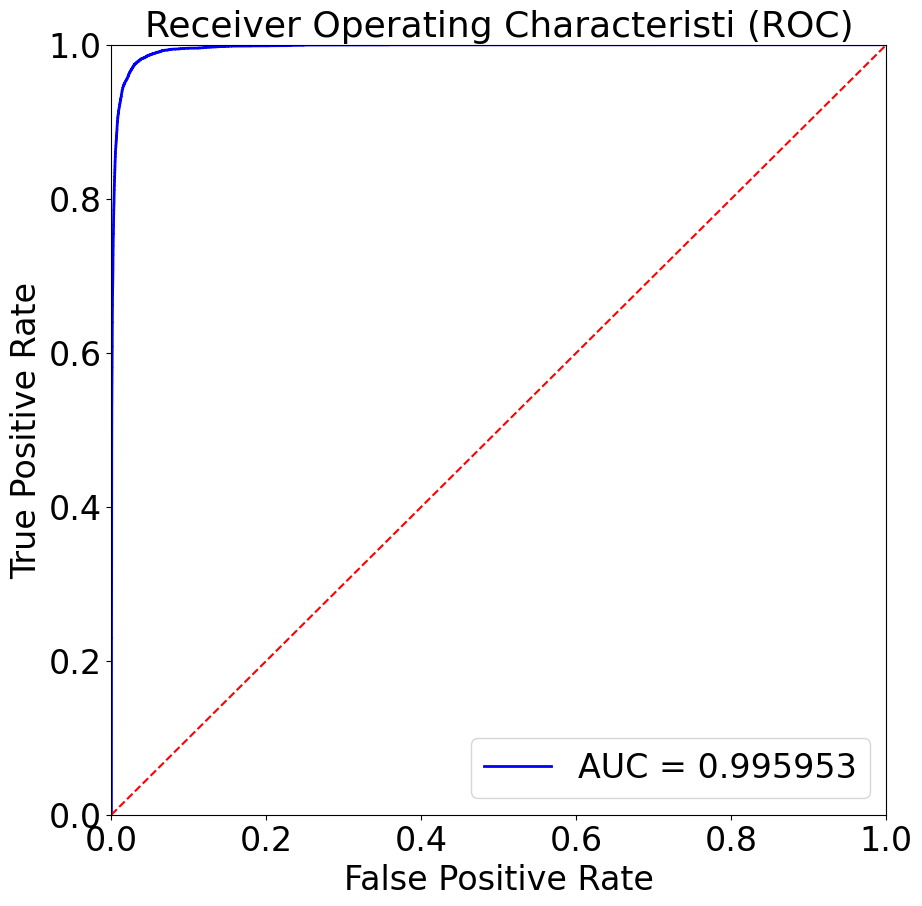

In [237]:
import sklearn.metrics as metrics
probs = model.predict_proba(X_eval)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_eval, preds)
roc_auc = metrics.auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10,10)
plt.title('Receiver Operating Characteristi (ROC)', fontsize=26)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=24)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=24)
plt.xlabel('False Positive Rate', fontsize=24)
plt.xticks(fontsize=24) 
plt.yticks(fontsize=24) 
plt.show()

In [238]:
print(model.get_best_score())
print(model.get_all_params())


{'learn': {'Accuracy:use_weights=true': 0.9904581462867353, 'Logloss:use_weights=false': 0.04576504792337086, 'Logloss:use_weights=true': 0.03889427284002524, 'Logloss': 0.03889427284002524, 'Accuracy:use_weights=false': 0.984816970700699, 'AUC': 0.9987200169172833}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 'ran

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36],
 [Text(0, 0, 'Lb_MAXDOCA'),
  Text(0, 1, 'L_CHI2'),
  Text(0, 2, 'L_END_VY'),
  Text(0, 3, 'L_BPVIP'),
  Text(0, 4, 'Lb_CHI2'),
  Text(0, 5, 'pim_ETA'),
  Text(0, 6, 'p_ETA'),
  Text(0, 7, 'Jpsi_PT'),
  Text(0, 8, 'L_END_VX'),
  Text(0, 9, 'L_P'),
  Text(0, 10, 'xi_LP'),
  Text(0, 11, 'L_BPVDIRA'),
  Text(0, 12, 'p_P'),
  Text(0, 13, 'Lb_P'),
  Text(0, 14, 'Jpsi_MAXDOCA'),
  Text(0, 15, 'xi_LbP'),
  Text(0, 16, 'p_PID_P'),
  Text(0, 17, 'Lb_ETA'),
  Text(0, 18, 'p_PT'),
  Text(0, 19, 'L_BPVIPCHI2'),
  Text(0, 20, 'Jpsi_ETA'),
  Text(0, 21, 'L_END_VZ'),
  Text(0, 22, 'pim_PT'),
  Text(0, 23, 'mup_PID_MU'),
  Text(0, 24, 'Lb_PT'),
  Text(0, 25, 'Lb_BPVVDRHO'),
  Text(0, 26, 'pim_P'),
  Text(0, 27, 'L_END_VRHO'),
  Text(0, 28, 'Jpsi_BPVDIRA'),
  Text(0, 29, 'pim_GHOSTPROB'),
  Te

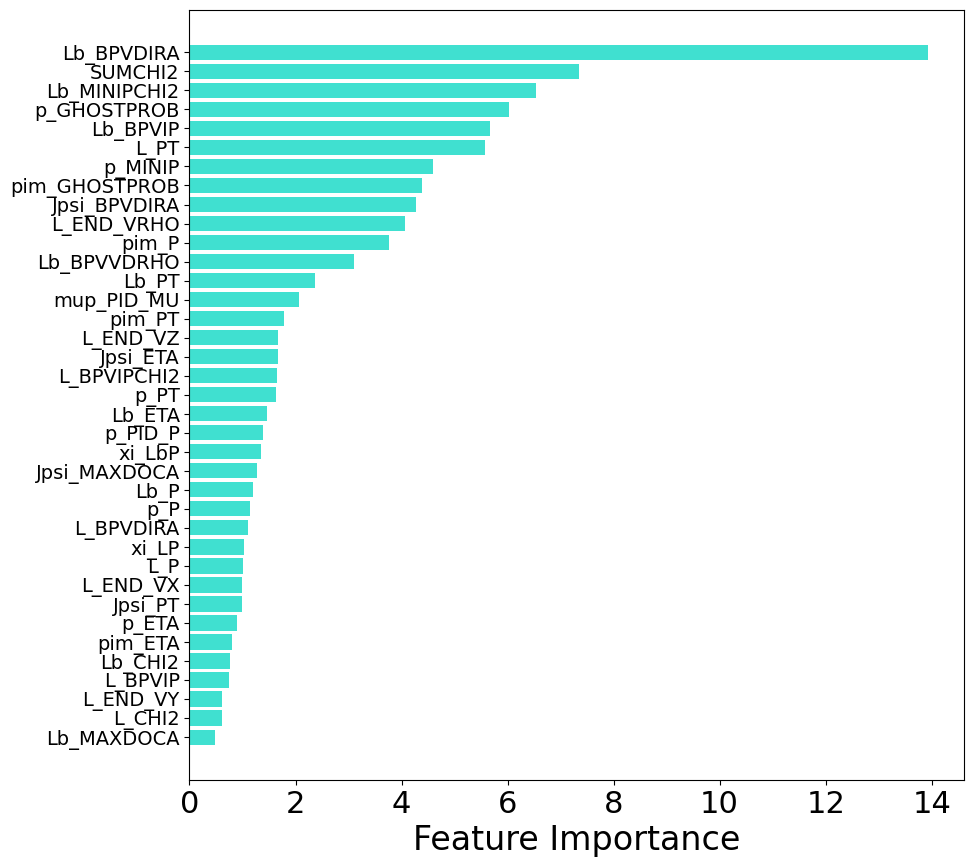

In [239]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (10,10)
plt.barh(X_eval.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("Feature Importance", fontsize=24)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
# plt.title("Feature Importance", fontsize=24)
plt.xticks(fontsize=22)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=14)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

In [240]:
signal_MVA_prob_eval = model.predict_proba(X_eval_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
X_eval_copy['signal_MVA'] = signal_MVA_probs

signal_MVA_prob_tr = model.predict_proba(X_tr_copy)
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_tr]
X_tr_copy['signal_MVA'] = signal_MVA_probs

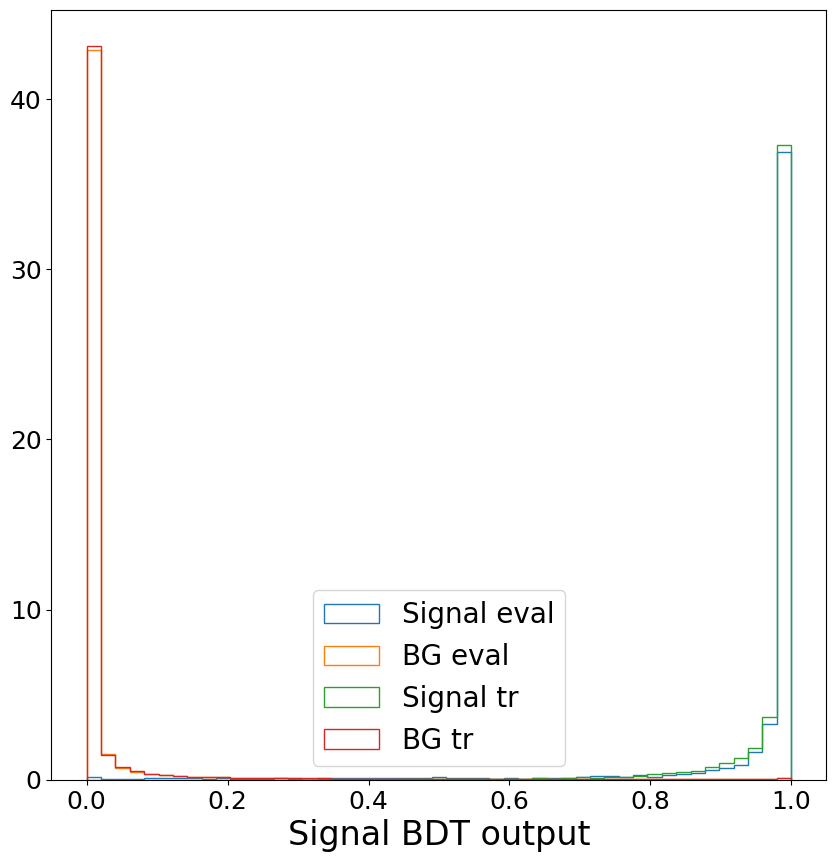

In [241]:
fig, ax = plt.subplots()

density = True

variable = 'signal_MVA'

bins = np.linspace(0,1,50)

n_sig,bins_sig, _ = ax.hist(X_eval_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal eval",histtype='step',density=density)
n_bg,bins_bg, _ = ax.hist(X_eval_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG eval",histtype='step',density=density)

ax.hist(X_tr_copy.query(f'SIGNAL')[variable], bins=bins, linewidth=1 ,label="Signal tr",histtype='step',density=density)
ax.hist(X_tr_copy.query(f'not SIGNAL')[variable], bins=bins, linewidth=1 ,label="BG tr",histtype='step',density=density)

ax.legend(fontsize=20)  # Ajusta el tamaño de fuente de la leyenda
ax.set_xlabel("Signal BDT output", fontsize=24)  # Ajusta el tamaño de fuente del eje x
plt.rcParams["figure.figsize"] = (15,10)
# Ajusta el tamaño de fuente de las marcas en los ejes x e y
# ax.tick_params(axis='both', which='major', labelsize=18)
plt.xticks(fontsize=18)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y

plt.show()

In [242]:
model.save_model('new_BDT_L_MASS',
           format="cbm",
           export_parameters=None,
           pool=None)

In [243]:
for SIGNAL in [True, False]:
    print(f'SIGNAL == {SIGNAL}', len(new_training.query(f'(SIGNAL == {SIGNAL})')))

SIGNAL == True 33665
SIGNAL == False 240062


In [244]:
data24_selected.columns

Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_MASS', 'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA',
       'Lb_P', 'Lb_PT', 'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT',
       'Jpsi_MAXDOCA', 'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2',
       'Lb_ETA', 'L_END_VZ', 'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT',
       'p_ETA', 'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB',
       'Cos_xi_LP', 'Cos_xi_LbP', 'xi_LP', 'xi_LbP', 'SUMCHI2', 'L_MASS'],
      dtype='object')

In [245]:
model.feature_names_

['Jpsi_PT',
 'L_END_VRHO',
 'L_BPVDIRA',
 'L_BPVIP',
 'L_BPVIPCHI2',
 'Lb_BPVDIRA',
 'Lb_BPVIP',
 'Lb_BPVVDRHO',
 'Lb_MAXDOCA',
 'Lb_P',
 'Lb_PT',
 'Lb_CHI2',
 'p_PID_P',
 'p_MINIP',
 'mup_PID_MU',
 'L_PT',
 'Jpsi_MAXDOCA',
 'Lb_MINIPCHI2',
 'L_P',
 'Jpsi_BPVDIRA',
 'L_CHI2',
 'Lb_ETA',
 'L_END_VZ',
 'L_END_VX',
 'L_END_VY',
 'Jpsi_ETA',
 'p_P',
 'p_PT',
 'p_ETA',
 'p_GHOSTPROB',
 'pim_P',
 'pim_PT',
 'pim_ETA',
 'pim_GHOSTPROB',
 'SUMCHI2',
 'xi_LbP',
 'xi_LP']

In [246]:
data24= pd.read_pickle('data24_magup_training.pkl')
data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']
data24_selected['EVENTNUMBER'] = data24['EVENTNUMBER']
data24_selected['p_PID_P'] = data24['p_PID_P']
data24_selected['SUMCHI2'] = data24['SUMCHI2']

prob = model.predict_proba(data24_selected)
print(prob)

signal_MVA_prob_eval = prob
signal_MVA_probs = [1 - i[0] for i in signal_MVA_prob_eval]
data24_selected['prob'] = signal_MVA_probs

[[9.99999892e-01 1.07724753e-07]
 [9.99985323e-01 1.46769645e-05]
 [9.99999853e-01 1.46616043e-07]
 ...
 [6.55248520e-02 9.34475148e-01]
 [9.41250206e-01 5.87497942e-02]
 [6.63012239e-01 3.36987761e-01]]


In [247]:

data24_selected_chi2  = data24_selected[data24_selected.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==data24_selected['SUMCHI2']].drop_duplicates('EVENTNUMBER')
data24_candidates  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

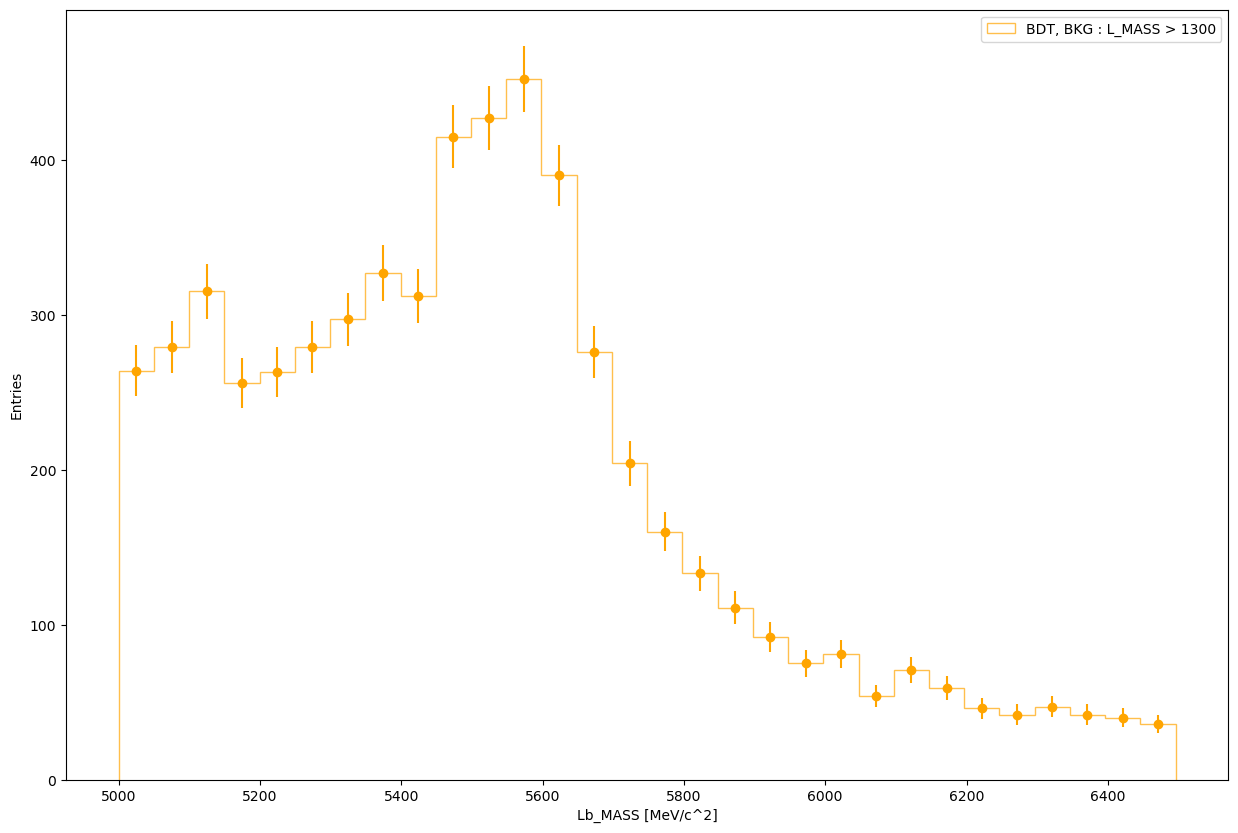

In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()
binning = 30

# Plot histograms
# hist1, bins1, _ = axes.hist(data24_candidates.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='Multiple Candidates Veto', color='green', alpha=0.7, histtype='step')
hist2, bins2, _ = axes.hist(data24_selected.query('(prob > 0.95)')['Lb_MASS'], bins=binning, label='BDT, BKG : L_MASS > 1300', color='orange', alpha=0.7, histtype='step')

# # Calculate the bin centers for the error bars
# bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# Plot error bars for the second histogram
axes.errorbar(
    bin_centers2,
    hist2,
    yerr=np.sqrt(hist2),
    fmt='o',
    color='orange',
    # label='MultiClass Data',
    drawstyle='steps-mid'
)

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


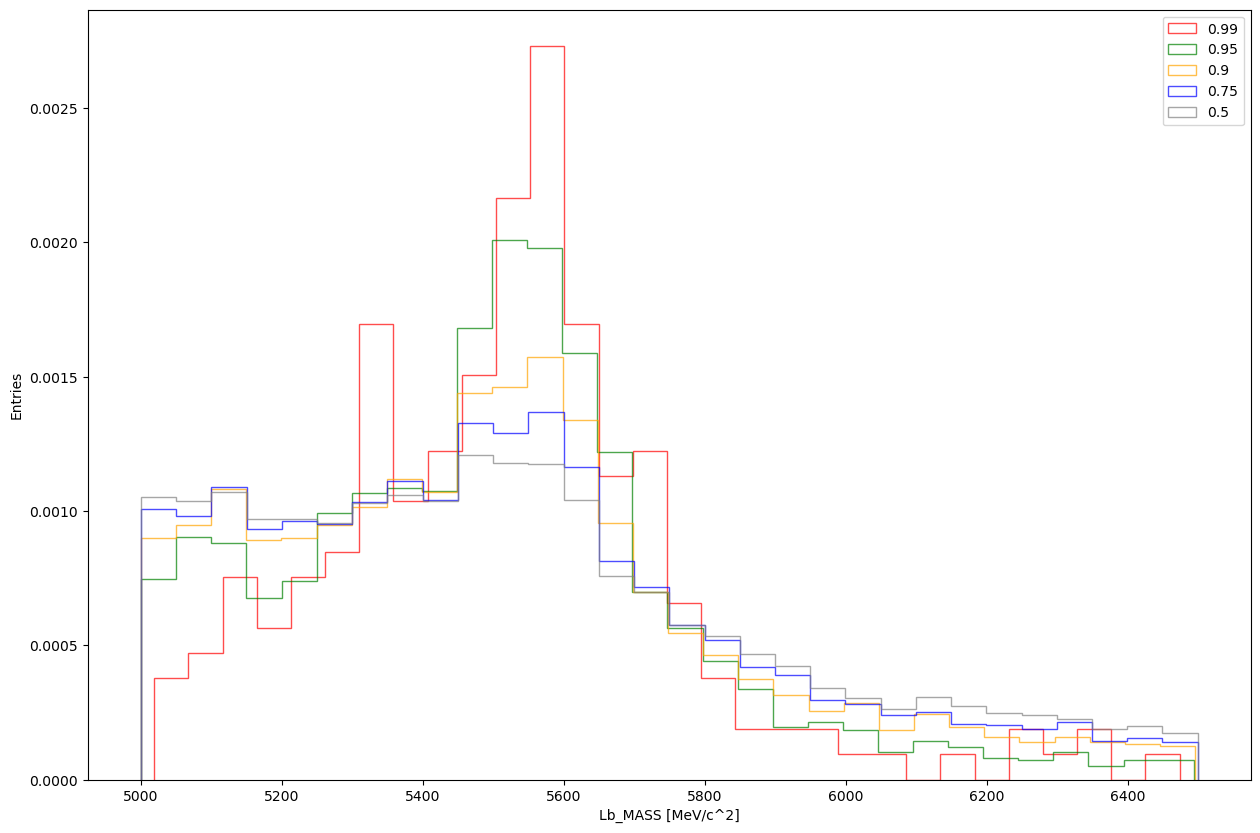

In [251]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the figure and axes
fig, axes = plt.subplots()
binning = 30

density = True

# Plot histograms
hist1, bins1, _ = axes.hist(data24_candidates.query('(prob > 0.999)')['Lb_MASS'], bins=binning, label='0.99', color='red', alpha=0.7, histtype='step', density = density)
hist1, bins1, _ = axes.hist(data24_candidates.query('(prob > 0.99)')['Lb_MASS'], bins=binning, label='0.95', color='green', alpha=0.7, histtype='step', density = density)
hist2, bins2, _ = axes.hist(data24_candidates.query('(prob > 0.95)')['Lb_MASS'], bins=binning, label='0.9', color='orange', alpha=0.7, histtype='step', density = density)
hist1, bins1, _ = axes.hist(data24_candidates.query('(prob > 0.9)')['Lb_MASS'], bins=binning, label='0.75', color='blue', alpha=0.7, histtype='step', density = density)
hist2, bins2, _ = axes.hist(data24_candidates.query('(prob > 0.8)')['Lb_MASS'], bins=binning, label='0.5', color='grey', alpha=0.7, histtype='step', density = density)

# # Calculate the bin centers for the error bars
# bin_centers1 = 0.5 * (bins1[1:] + bins1[:-1])
# bin_centers2 = 0.5 * (bins2[1:] + bins2[:-1])

# # Plot error bars for the first histogram
# axes.errorbar(
#     bin_centers1,
#     hist1,
#     yerr=np.sqrt(hist1),
#     fmt='o',
#     color='green',
#     # label='Binary Data',
#     drawstyle='steps-mid'
# )

# # Plot error bars for the second histogram
# axes.errorbar(
#     bin_centers2,
#     hist2,
#     yerr=np.sqrt(hist2),
#     fmt='o',
#     color='orange',
#     # label='MultiClass Data',
#     drawstyle='steps-mid'
# )

# Set labels and legend
plt.xlabel('Lb_MASS [MeV/c^2]')
plt.ylabel('Entries')
plt.legend()

# Display the plot
plt.show()


In [250]:
print(model.get_best_score())
print(model.get_all_params())

{'learn': {'Accuracy:use_weights=true': 0.9904581462867353, 'Logloss:use_weights=false': 0.04576504792337086, 'Logloss:use_weights=true': 0.03889427284002524, 'Logloss': 0.03889427284002524, 'Accuracy:use_weights=false': 0.984816970700699, 'AUC': 0.9987200169172833}}
{'nan_mode': 'Min', 'eval_metric': 'Logloss', 'iterations': 1000, 'sampling_frequency': 'PerTree', 'leaf_estimation_method': 'Newton', 'od_pval': 0, 'random_score_type': 'NormalWithModelSizeDecrease', 'grow_policy': 'SymmetricTree', 'penalties_coefficient': 1, 'boosting_type': 'Plain', 'model_shrink_mode': 'Constant', 'feature_border_type': 'GreedyLogSum', 'bayesian_matrix_reg': 0.10000000149011612, 'eval_fraction': 0, 'force_unit_auto_pair_weights': False, 'l2_leaf_reg': 3, 'random_strength': 1, 'od_type': 'IncToDec', 'rsm': 1, 'boost_from_average': False, 'model_size_reg': 0.5, 'pool_metainfo_options': {'tags': {}}, 'subsample': 0.800000011920929, 'use_best_model': False, 'od_wait': 20, 'class_names': [False, True], 'ran